# Spatialize Empirical Module

<span style="color: purple;">**This notebook has been tested with `spatialize v1.2.0`**</span>

An ESI estimate at a target location is, in practice, the average of many per-partition predictions, which we call the **ESI samples** (`ESIResult.esi_samples()`). The `ESIResult` object includes the `estimation()` method, which aggregates the ESI samples producing a point estimate, and the `precision()` method which quantifies the uncertainty of said estimates. Both methods reduce the ensemble to point values. 

The `spatialize.empirical` module offers additional tools to ***characterize the distribution of the ESI samples*** (or any other sample) by fitting a queryable probability distribution. It includes two main classes:
- **`FittedModelFactory`** — configures *how* to fit the sample (NaN handling, KDE vs. Gaussian-mixture density model, optional ensemble widening).
- **`EmpiricalModel`** — the fitted distribution itself, exposing a numerical PDF/CDF/inverse-CDF plus moments, entropy-based and credible intervals, confidence measures, and sampling.

This module is used by `spatialize.gs.ess`([Ensemble Spatial Simulation](../introductory/ess_overview.ipynb)), ESI's [Pareto optimization](../esi_fundamentals/esi_pareto_optimization.ipynb), and `spatialize.gs.spa` ([Posterior Sample Analyzer](../introductory/spa_overview.ipynb)), but it can also be used for other purposes. This notebook demonstrates it's full functionality, as guidance for general use.


## Setup

This notebook demonstrates the functionality of the `spatialize.empirical` module over an anisotropic Gaussian simulation. Adaptive ESI ([ESA](../esi_implementations/adaptive_esi_2d.ipynb)) is run using a reduced sample as conditioning data for interpolation. This yields an `ESIResult` object whose `esi_samples()` are then analyzed using the `spatialize.empirical` module.


In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt

from spatialize.data import load_simulated_anisotropic_data
from spatialize.gs.esi import esi_nongriddata
from spatialize.empirical import FittedModelFactory, EmpiricalModel
from spatialize import viz

# load simulations from the spatialize package
_, _, data_reduced, ground_truth = load_simulated_anisotropic_data()

using_sim = 'sim10'
points = data_reduced[0][['x', 'y']].values
values = data_reduced[0][[using_sim]].values[:, 0]
xi = ground_truth[['x', 'y']].values

result = esi_nongriddata(points, values, xi,
                         local_interpolator="adaptiveidw",
                         n_partitions=300,
                         alpha=0.3,
                         seed=42)

esi_samples = result.esi_samples()
print(f"esi_samples shape : {esi_samples.shape}  (n_locations x n_partitions)")

finished 100% of 300 iterations ... 

done (elapsed time:  6s)
finished 100% of 300 iterations ... 

done (elapsed time:  6s)
esi_samples shape : (40000, 300)  (n_locations x n_partitions)


We pick a single target location and keep its raw ensemble as `ensemble` for the rest of this tutorial.

In [2]:
# restrict to locations with a complete (NaN-free) ensemble, then pick the widest one so the shape of the distribution is easy to see.
# IQR (not std) so a long thin tail or a pile of near-duplicate values can't dominate the pick.
complete = ~np.isnan(esi_samples).any(axis=1)
q25, q75 = np.percentile(esi_samples[complete], [25, 75], axis=1)
loc_idx = int(np.flatnonzero(complete)[np.argmax(q75 - q25)])
ensemble = esi_samples[loc_idx, :]
point_estimate = result.estimation()[loc_idx]

print(f"Location index    : {loc_idx}")
print(f"Ensemble size     : {ensemble.size}")
print(f"Point estimate    : {point_estimate:.4f}")
print(f"Ensemble std : {np.nanstd(ensemble):.4f}")

Location index    : 28365
Ensemble size     : 300
Point estimate    : -0.2707
Ensemble std : 0.7195


## Part 1 — Fitting a Distribution to the Ensemble

**`EmpiricalModel`**`(sample=ensemble)` fits a density model to the ensemble (KDE by default, via a default **`FittedModelFactory`**) and builds a numerical PDF, CDF, and inverse CDF from it over a support grid.

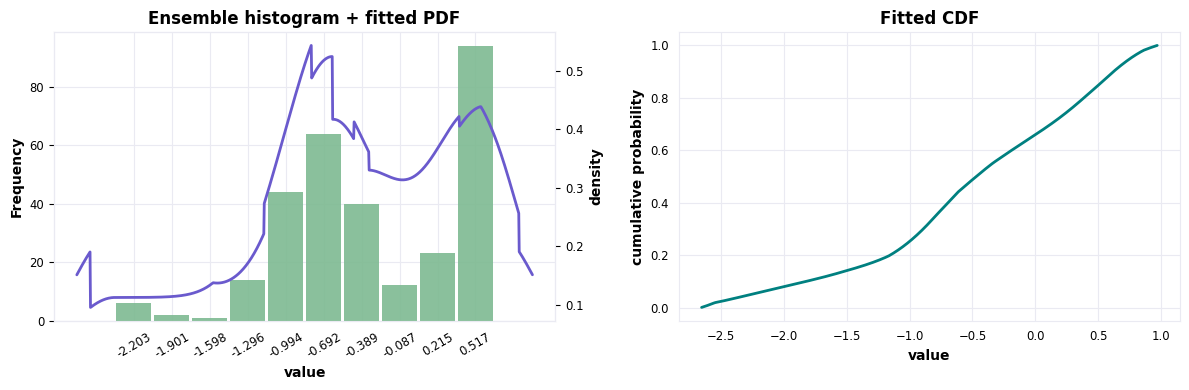

In [3]:
model = EmpiricalModel(sample=ensemble, seed=42)

with viz.PlotStyle(theme='whitegrid') as theme:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    viz.plot_histogram(model.data_, ax1, color=theme.color)
    ax1_twin = ax1.twinx()
    ax1_twin.grid(False)
    ax1_twin.plot(model.x_, model.pdf_, color="slateblue", lw=2, label='fitted PDF')
    ax1_twin.set_ylabel('density')
    ax1.set_title('Ensemble histogram + fitted PDF')
    ax1.set_xlabel('value')

    ax2.plot(model.x_, model.cdf_, color="teal", lw=2)
    ax2.set_title('Fitted CDF')
    ax2.set_xlabel('value')
    ax2.set_ylabel('cumulative probability')

    plt.tight_layout(w_pad=2)
    plt.show()

The fitted distribution exposes the usual summary statistics — computed from the numerical PDF, not the raw ensemble — plus `mode()` and `percentile()`.

In [4]:
print(f"mean       : {model.mean():.4f}   (vs. ESI point estimate: {point_estimate:.4f})")
print(f"median     : {model.median():.4f}")
print(f"mode       : {model.mode():.4f}")
print(f"std        : {model.std():.4f}")
print(f"variance   : {model.variance():.4f}")
print(f"skewness   : {model.skewness():.4f}")
print(f"kurtosis   : {model.kurtosis():.4f}  (excess)")
print(f"10th / 90th percentile : {model.percentile(0.10):.4f} / {model.percentile(0.90):.4f}")

mean       : -0.4922   (vs. ESI point estimate: -0.2707)
median     : -0.4693
mode       : -0.7902
std        : 0.8916
variance   : 0.7950
skewness   : -0.4800
kurtosis   : -0.4533  (excess)
10th / 90th percentile : -1.8227 / 0.6219


## Part 2 — Choosing a Point Model

**`FittedModelFactory`**`(point_model_name=...)` controls which density model is fit to the sample:

- `"kde"` — Kernel Density Estimation (default). Fast, follows the empirical spread closely.
- `"emm"` — Gaussian Mixture Model via Expectation-Maximization. Smoother, good for multi-modal ensembles.
- `"vim"` — Gaussian Mixture Model via Variational Inference. More robust for small/sparse ensembles.

The following figure shows how the fitted distribution varies depending on this choice:

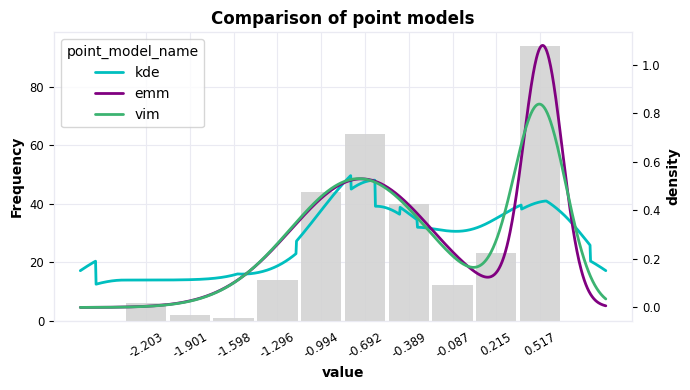

In [5]:
with viz.PlotStyle(theme='whitegrid'):
    fig, ax = plt.subplots(figsize=(7, 4))
    viz.plot_histogram(ensemble, ax, color='lightgray')
    ax_twin = ax.twinx()
    ax_twin.grid(False)

    for name, color in [("kde", "c"), ("emm", "purple"), ("vim", "mediumseagreen")]:
        factory = FittedModelFactory(point_model_name=name, n_components=2, seed=42)
        m = EmpiricalModel(sample=ensemble, fitted_model_factory=factory, seed=42)
        ax_twin.plot(m.x_, m.pdf_, color=color, lw=2, label=name)

    ax_twin.legend(title='point_model_name')
    ax_twin.set_ylabel('density')
    ax.set_xlabel('value')
    ax.set_title('Comparison of point models')
    plt.tight_layout()
    plt.show()

**`FittedModelFactory`** also controls how NaNs in the sample are handled, via `nan_model_name`: `"replace"` (default) fills them with a statistic (`nan_replace_func_name="median"` or `"mean"`), while `"ignore"` drops them entirely.

In [6]:
ensemble_with_nans = ensemble.copy()
rng = np.random.default_rng(0)
nan_idx = rng.choice(ensemble.size, size=max(1, ensemble.size // 20), replace=False)
ensemble_with_nans[nan_idx] = np.nan

for nan_mode in ("replace", "ignore"):
    factory = FittedModelFactory(nan_model_name=nan_mode, seed=42)
    m = EmpiricalModel(sample=ensemble_with_nans, fitted_model_factory=factory, seed=42)
    print(f"nan_model_name={nan_mode!r:10s}  fitted on {m.data_.size} values, mean={m.mean():.4f}")

nan_model_name='replace'   fitted on 300 values, mean=-0.4985
nan_model_name='ignore'    fitted on 285 values, mean=-0.4947


## Part 3 — Widening

By construction, interpolators smooth out small-scale variations. While some models, like ESA, reduce this problem, it's still an inevitable effect. As a consequence, the spread across ensemble members misses that fine, point-to-point variability. `widening` adds that missing variance back, by fitting each ensemble member as a small parametric component (Gamma or SkewNormal) calibrated to a target local variance, then resampling from that mixture.

**`FittedModelFactory`**`(widening=...)` controls whether and how this correction is applied:

- `False` — no widening (default).
- `"gamma"` — widens with Gamma components; requires non-negative values.
- `"skew_normal"` — widens with SkewNormal components; handles negative values, optionally shaped to match a target local skewness.
- `"auto"` — picks `"gamma"` when the sample is non-negative, `"skew_normal"` otherwise.

Both `"gamma"` and `"skew_normal"` need a target local variance to calibrate against (and `"skew_normal"` optionally a target local skewness) — estimated from the nearest *observed* neighbors of the target location. `spatialize.empirical` offers two helpers for that:

In [7]:
from spatialize.empirical import _local_target_variance, _local_target_skewness

target_var = _local_target_variance(points, values, xi[loc_idx:loc_idx + 1], knn=8)[0]
target_skew = _local_target_skewness(points, values, xi[loc_idx:loc_idx + 1], knn=8)[0]

print(f"Ensemble (between-partition) variance : {np.var(ensemble):.4f}")
print(f"Target local variance (k-NN of obs.)  : {target_var:.4f}")

Ensemble (between-partition) variance : 0.5177
Target local variance (k-NN of obs.)  : 1.1590


The target variance exceeds the ensemble's own, so widening has something to correct.

### Skew-aware widening

This particular ensemble takes negative values (typical of a Gaussian-simulated field), so we compare `widening=False` against `"skew_normal"` here. The widened distributions come out visibly wider/shorter than the raw fit, and their empirical variance moves toward `target_var`.

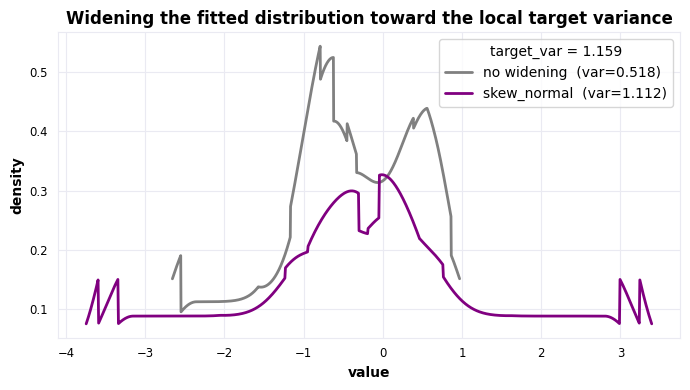

In [8]:
configs = [
    (False, None, "no widening", "gray"),
    ("skew_normal", target_skew, "skew_normal", "purple")
]

with viz.PlotStyle(theme='whitegrid'):
    fig, ax = plt.subplots(figsize=(7, 4))

    for widening, tskew, label, color in configs:
        factory = FittedModelFactory(widening=widening, seed=42)
        m = EmpiricalModel(sample=ensemble, fitted_model_factory=factory,
                           target_var=target_var if widening else None,
                           target_skew=tskew, seed=42)
        ax.plot(m.x_, m.pdf_, color=color, lw=2, label=f"{label}  (var={np.var(m.data_):.3f})")

    ax.legend(title=f"target_var = {target_var:.3f}")
    ax.set_xlabel('value')
    ax.set_ylabel('density')
    ax.set_title('Widening the fitted distribution toward the local target variance')
    plt.tight_layout()
    plt.show()

### Gamma widening on a non-negative variable

`"gamma"` widening only supports non-negative values, so it isn't a fit for the signed ensemble above. We illustrate it on a small synthetic non-negative ensemble:

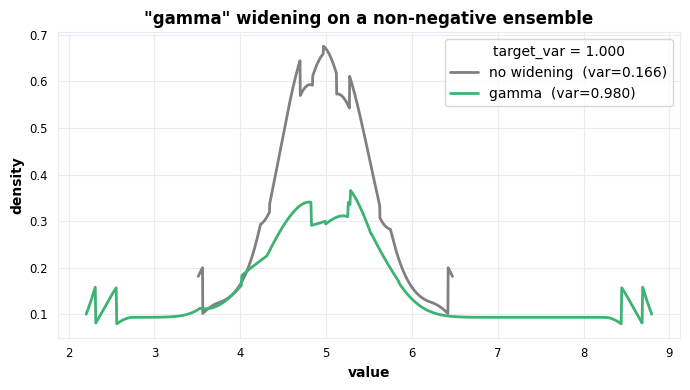

In [9]:
# a synthetic ensemble mimicking a non-negative variable (e.g. porosity or precipitation):
# partition means clustered around 5.0 with modest between-partition spread
rng = np.random.default_rng(0)
positive_ensemble = rng.normal(loc=5.0, scale=0.4, size=ensemble.size)
positive_target_var = 1.0  # a target local variance larger than the ensemble's own, to trigger widening

with viz.PlotStyle(theme='whitegrid'):
    fig, ax = plt.subplots(figsize=(7, 4))

    for widening, label, color in [(False, "no widening", "gray"), ("gamma", "gamma", "mediumseagreen")]:
        factory = FittedModelFactory(widening=widening, seed=42)
        m = EmpiricalModel(sample=positive_ensemble, fitted_model_factory=factory,
                           target_var=positive_target_var if widening else None, seed=42)
        ax.plot(m.x_, m.pdf_, color=color, lw=2, label=f"{label}  (var={np.var(m.data_):.3f})")

    ax.legend(title=f"target_var = {positive_target_var:.3f}")
    ax.set_xlabel('value')
    ax.set_ylabel('density')
    ax.set_title('"gamma" widening on a non-negative ensemble')
    plt.tight_layout()
    plt.show()

As seen in the example, `"gamma"` widening produces single, wider, unimodal distribution whose variance moves toward `target_var`.

## Part 4 — Uncertainty-Quantification API

Given a fitted **`EmpiricalModel`**, `spatialize.empirical` provides several ways to summarize *where the probability mass concentrates*, beyond simple moments. We use the Part 1 model (unwidened, `kde`) to showcase these.


### Differential entropy
The **`EmpiricalModel`**`.central_entropy_interval()` method returns the narrowest interval containing a target share of differential entropy:

In [10]:
h = model.entropy()
central = model.central_entropy_interval(alpha=0.5)

print(f"Total entropy                 : {h:.4f}")
print(f"50%-of-entropy interval       : [{central['interval'][0]:.4f}, {central['interval'][1]:.4f}]")

Total entropy                 : 0.0246
50%-of-entropy interval       : [-0.9898, 0.3244]


An entropy interval can also be grown outward from a chosen point `x0`, rather than found as the single narrowest interval overall — useful when the interval needs to be anchored at a specific value of interest, e.g. a decision threshold, instead of wherever the distribution happens to concentrate its mass. With the same target share of entropy, the two intervals cover different ranges because they're built around different points:

In [11]:
x0 = 0.0  # e.g. a decision threshold: is the field positive or negative at this location?
around_x0 = model.entropy_informative_interval(x0=x0, alpha=0.5)
print(f"50%-of-entropy interval around x0={x0}: "
      f"[{around_x0['interval'][0]:.4f}, {around_x0['interval'][1]:.4f}]")

50%-of-entropy interval around x0=0.0: [-0.6014, 0.7819]


### Credible interval
The **`EmpiricalModel`**`.credible_interval()` method returns the narrowest interval around an estimator holding at least `alpha` probability mass.

In [12]:
credible = model.credible_interval(estimator=point_estimate, alpha=0.95)
print(f"95% credible interval around point estimate: "
      f"[{credible['interval'][0]:.4f}, {credible['interval'][1]:.4f}]  (mass={credible['mass']:.4f})")

map_est = model.map_estimator()
print(f"MAP estimate : value={map_est['value']:.4f}, density={map_est['density']:.4f}")
print(f"3rd central moment : {model.central_moment(3):.6f}")

95% credible interval around point estimate: [-2.2605, 0.9707]  (mass=0.9502)
MAP estimate : value=-0.7902, density=0.5428
3rd central moment : -0.340212


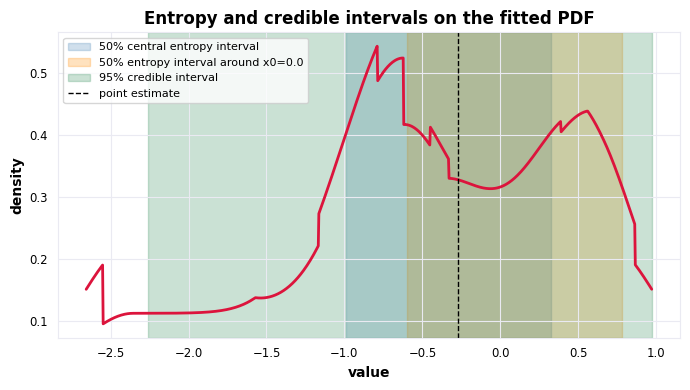

In [13]:
with viz.PlotStyle(theme='whitegrid'):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(model.x_, model.pdf_, color='crimson', lw=2)
    ax.axvspan(*central['interval'], color='steelblue', alpha=0.25, label='50% central entropy interval')
    ax.axvspan(*around_x0['interval'], color='darkorange', alpha=0.25, label=f'50% entropy interval around x0={x0}')
    ax.axvspan(*credible['interval'], color='seagreen', alpha=0.25, label='95% credible interval')
    ax.axvline(point_estimate, color='black', ls='--', lw=1, label='point estimate')
    ax.legend(fontsize=8)
    ax.set_xlabel('value')
    ax.set_ylabel('density')
    ax.set_title('Entropy and credible intervals on the fitted PDF')
    plt.tight_layout()
    plt.show()

## Part 5 — Confidence Measures

The **`EmpiricalModel`**`.compute_confidence_measures(x0, ...)` method combines the credible interval and the entropy interval around a point `x0` into three scalar confidence scores — each rewarding a *narrow* interval that still captures a *large* share of probability mass / entropy, just combined differently (product-normalized, harmonic, and log-ratio respectively):

In [14]:
conf = model.compute_confidence_measures(x0=point_estimate,
                                         alpha_credible_target=0.95,
                                         alpha_entropy_target=0.05)

for name, score in conf['confidence_scores'].items():
    print(f"{name:28s}: {score:.4f}")

simple_relative_confidence  : 0.5773
relative_harmonic_confidence: 0.1383
log_ratio_confidence        : 0.0941


`mc_estimator` sweeps `x0` over the model's support grid and returns the point that *maximizes* a chosen confidence measure — an alternative estimator to the mean/median/mode that explicitly accounts for both interval widths.

In [15]:
best = model.mc_estimator('simple_relative', alpha_credible_target=0.95, alpha_entropy_target=0.05)
print(f"optimal_estimator (simple_relative) : {best['optimal_estimator']:.4f}")
print(f"max_confidence_score                : {best['max_confidence_score']:.4f}")
print(f"(for reference) mean / median / mode : "
      f"{model.mean():.4f} / {model.median():.4f} / {model.mode():.4f}")

optimal_estimator (simple_relative) : -0.7502
max_confidence_score                : 0.6555
(for reference) mean / median / mode : -0.4922 / -0.4693 / -0.7902


## Building an EmpiricalModel from a pre-fitted sklearn model

If you already have a fitted `GaussianMixture` or `BayesianGaussianMixture`, pass it directly via `skl_model=` instead of `sample=` — useful when a caller already manages its own density model and just needs **`EmpiricalModel`**'s PDF/CDF/interval machinery on top of it.

In [16]:
from sklearn.mixture import GaussianMixture

skl_gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42).fit(ensemble.reshape(-1, 1))
model_from_skl = EmpiricalModel(skl_model=skl_gmm)

print(f"mean (from pre-fitted sklearn model): {model_from_skl.mean():.4f}")
print(f"mean (from EmpiricalModel(sample=)) : {model.mean():.4f}")

mean (from pre-fitted sklearn model): -0.2707
mean (from EmpiricalModel(sample=)) : -0.4922


Note: `skl_model=` requires `.sample(n)` to return an `(X, y)` tuple, as `GaussianMixture`/`BayesianGaussianMixture` do — a fitted `sklearn.neighbors.KernelDensity` does not work here (its `.sample(n)` returns a plain array), so use **`EmpiricalModel`**`(sample=..., fitted_model_factory=`**`FittedModelFactory`**`(point_model_name="kde"))` for a KDE-based fit instead.

## Further Reading
- **ESI Original**: Egaña, Á.F., Navarro, F., Maleki, M., et al. (2021). *Ensemble Spatial Interpolation: A New Approach to Natural or Anthropogenic Variable Assessment*. Natural Resources Research **30**(5), 3777-3793. https://doi.org/10.1007/s11053-021-09860-2
- **Adaptive ESA**: Egaña, Á.F., Valenzuela, M.J., Maleki, M. et al. (2025). *Adaptive ensemble spatial analysis*. Scientific Reports **15**, 26599. https://doi.org/10.1038/s41598-025-08844-z
- **Spatialize Library**: Navarro, F., Egaña, Á.F., et al. (2025). *Spatialize v1.0: A Python/C++ Library for Ensemble Spatial Interpolation*. arXiv:2507.17867. https://arxiv.org/abs/2507.17867
- **ESS / Spatial Distributional Estimation**: Egaña, Á.F., Díaz, G., Navarro, F., Maleki, M., Sánchez-Pérez, J.F. (2025). *Spatial distributional estimation via ensemble spatial analysis*. AIMS Mathematics **10**(11), 26351-26388. https://doi.org/10.3934/math.20251159